In [43]:
import re
from collections import defaultdict
from enum import Enum
from pathlib import Path

import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib import font_manager
import numpy as np
import pandas as pd

In [44]:
font_path = Path.cwd().parent / "fonts"
cmu_font_file = font_path / "cmunrm.otf"
font_manager.fontManager.addfont(cmu_font_file)

plt.rcParams["font.family"] = "CMU Serif"
plt.rcParams["mathtext.fontset"] = "cm"

mpl.rcParams['grid.linewidth'] = 0.5

mpl.rcParams['axes.linewidth'] = 0.5
mpl.rcParams['axes.edgecolor'] = 'lightgray'

mpl.rcParams["legend.frameon"] = True
mpl.rcParams["legend.facecolor"] = "white"
mpl.rcParams["legend.edgecolor"] = "gray"
mpl.rcParams["legend.framealpha"] = 1.0
mpl.rcParams["legend.fontsize"] = 10
mpl.rcParams['legend.markerscale'] = 0.8

In [45]:
class Dataset(Enum):
    DL19 = "dl19"
    DL20 = "dl20"
    TREC_COVID = "trec-covid"
    NF_CORPUS = "nfcorpus"
    SIGNAL = "signal"
    NEWS = "news"
    ROBUST04 = "robust04"
    SCIFACT = "scifact"
    TOUCHE = "touche"
    DB_PEDIA = "dbpedia-entity"

    @classmethod
    def beir_datasets(cls) -> list["Dataset"]:
        return [
            cls.TREC_COVID,
            cls.NF_CORPUS,
            cls.SIGNAL,
            cls.NEWS,
            cls.ROBUST04,
            cls.SCIFACT,
            cls.TOUCHE,
            cls.DB_PEDIA,
        ]

class AggregationStrategy(Enum):
    MEAN = "mean_aggregation"
    MAX = "max_aggregation"
    SMOOTH_MAX = "smooth_max_aggregation"

In [46]:
def create_log_path(
    log_dir: str | Path,
    aggregation_strategy: AggregationStrategy,
    dataset: Dataset | str,
    view: int | None = None,
) -> Path:
    log_dir = Path(log_dir)

    if isinstance(dataset, str):
        dataset = Dataset(dataset)
    if not isinstance(aggregation_strategy, AggregationStrategy):
        raise TypeError("Argument aggregation_strategy expected to be of type `AggregationStrategy`")

    filename = Path(aggregation_strategy.value)

    if view is not None:
        filename = filename / f"view_{view}" / f"{dataset.value}.txt"
    else:
        filename = filename / f"{dataset.value}.txt"
    return log_dir / filename

In [47]:
class MetricsLog:
    def __init__(self, text: str):
        self.text = text

        self.metrics = self._metrics()

    @classmethod
    def from_file(cls, path: str | Path) -> "MetricsLog":
        path = Path(path)
        if not path.exists():
            raise FileNotFoundError(f"File does not exist: `{path}`")
        text = path.read_text(encoding="utf-8")
        return cls(text)

    @classmethod
    def from_run(
        cls,
        log_dir: str | Path,
        aggregation_strategy: AggregationStrategy,
        dataset: Dataset | str,
        view: int | None = None,
    ) -> "MetricsLog":
        log_path = create_log_path(log_dir, aggregation_strategy, dataset, view)
        return cls.from_file(log_path)
    
    def _metrics(self):
        metrics = defaultdict(dict)

        pattern = re.compile(r"([A-Za-z]+)@(\d+):\s*([0-9.]+)")

        for line in self.text.splitlines():
            match = pattern.search(line)
            if match:
                name, k, value = match.groups()
                metrics[name][int(k)] = float(value)

        return dict(metrics)
    

        

In [48]:
def average_metrics(logs: list[MetricsLog]) -> dict[str, dict[int, float]]:
    acc = defaultdict(lambda: defaultdict(list))

    for log in logs:
        for metric, ks in log.metrics.items():
            for k, value in ks.items():
                acc[metric][k].append(value)

    averaged = {
        metric: {
            k: float(np.mean(values))
            for k, values in ks.items()
            if values
        }
        for metric, ks in acc.items()
    }

    return averaged

In [49]:
LOG_DIR = Path("metrics")

In [50]:
log = MetricsLog.from_run(LOG_DIR, AggregationStrategy.MEAN, Dataset.DL19)
log.metrics

{'NDCG': {1: 0.8062, 2: 0.7756, 3: 0.779, 5: 0.7775, 10: 0.7319},
 'MAP': {1: 0.0259, 2: 0.0439, 3: 0.0667, 5: 0.1083, 10: 0.1639},
 'Recall': {1: 0.0259, 2: 0.0439, 3: 0.0692, 5: 0.1143, 10: 0.1741},
 'P': {1: 1.0, 2: 0.9651, 3: 0.9612, 5: 0.9209, 10: 0.8233},
 'MRR': {1: 1.0, 2: 1.0, 3: 1.0, 5: 1.0, 10: 1.0},
 'Accuracy': {1: 1.0, 2: 1.0, 3: 1.0, 5: 1.0, 10: 1.0}}

In [116]:
print("BEIR Average:")

for aggregation_strategy in AggregationStrategy:
    mean_metrics = [
        MetricsLog.from_run(LOG_DIR, aggregation_strategy, dataset)
        for dataset in Dataset.beir_datasets()
    ]
    beir_average = average_metrics(mean_metrics)["NDCG"][10]
    agg_name = aggregation_strategy.name.capitalize().replace("_", " ")
    print(f"Aggregation {agg_name}: {beir_average}")

BEIR Average:
Aggregation Mean: 0.509325
Aggregation Max: 0.508125
Aggregation Smooth max: 0.5062


In [52]:
FIG_DPI = 100
# FIG_DPI = 300

def plot_dataset_and_aggregation(
    datasets,
    metric: str = "NDCG",
    metric_k: int = 10,
):
    plt.figure(figsize=(9, 4), dpi=FIG_DPI)

    n_datasets = len(datasets)
    n_aggs = len(AggregationStrategy)

    x = np.arange(n_datasets)
    width = 0.8 / n_aggs

    for i, aggregation in enumerate(AggregationStrategy):
        values = []

        for dataset in datasets:
            try:
                log = MetricsLog.from_run(
                    LOG_DIR,
                    aggregation,
                    dataset,
                )
            except FileNotFoundError:
                values.append(np.nan)
                continue

            values.append(log.metrics[metric][metric_k])

        if all(np.isnan(values)):
            continue

        plt.bar(
            x + i * width,
            values,
            width=width,
            label=aggregation.name.capitalize().replace("_", " "),
        )

    plt.xticks(
        x + width * (n_aggs - 1) / 2,
        [dataset.value for dataset in datasets],
        # rotation=30,
        ha="center",
    )

    plt.ylabel(f"{metric}@{metric_k}")
    plt.xlabel("Dataset")
    plt.ylim(0, 1.0)
    plt.grid(axis="y", linestyle="--", alpha=0.5)
    plt.legend(title="Aggregation")
    plt.tight_layout()
    plt.show()



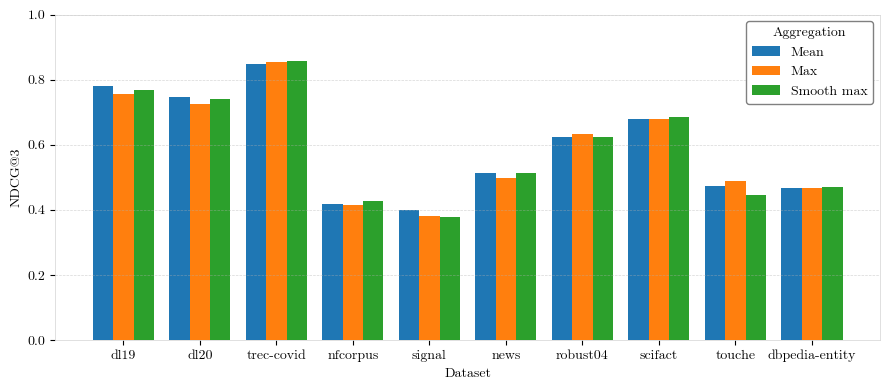

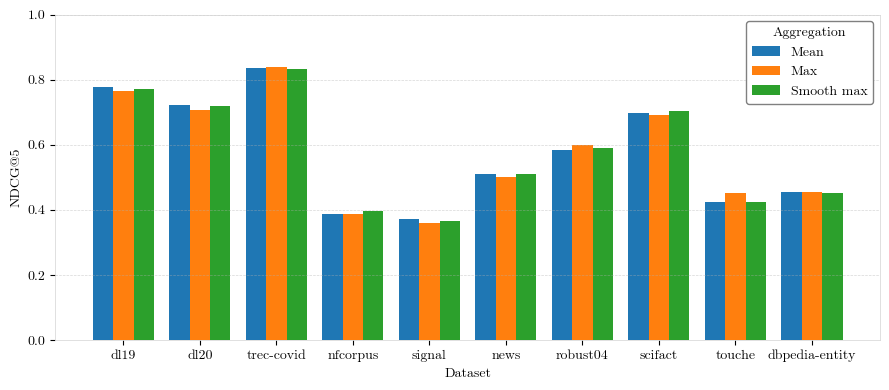

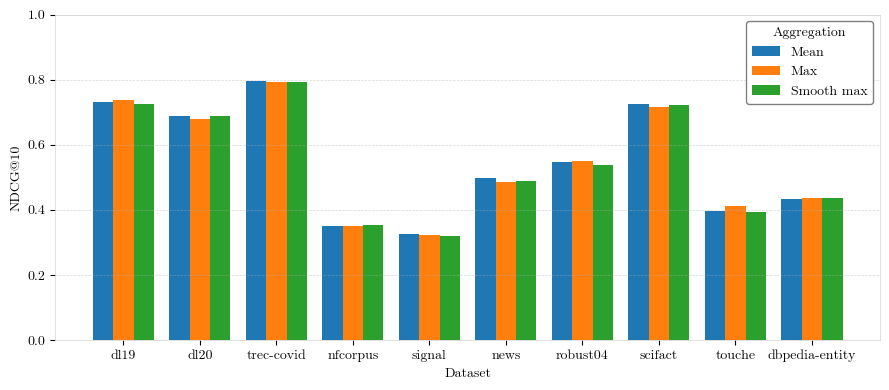

In [53]:
plot_dataset_and_aggregation(list(Dataset), "NDCG", 3)
plot_dataset_and_aggregation(list(Dataset), "NDCG", 5)
plot_dataset_and_aggregation(list(Dataset), "NDCG", 10)

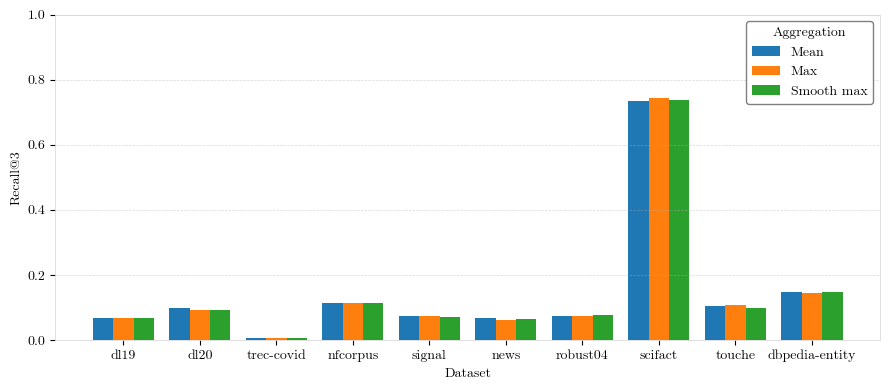

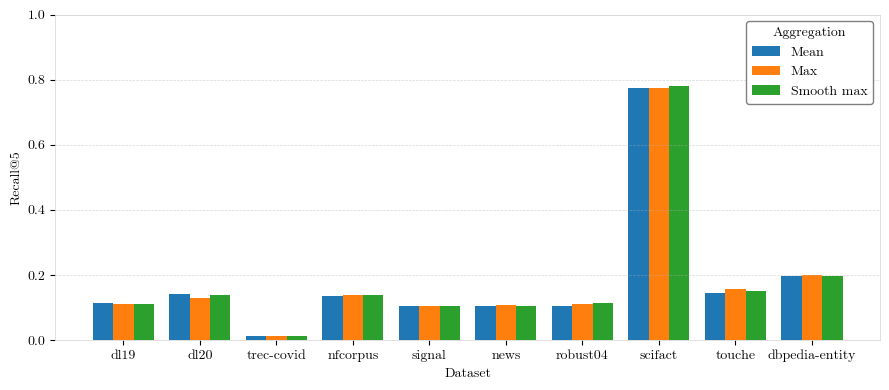

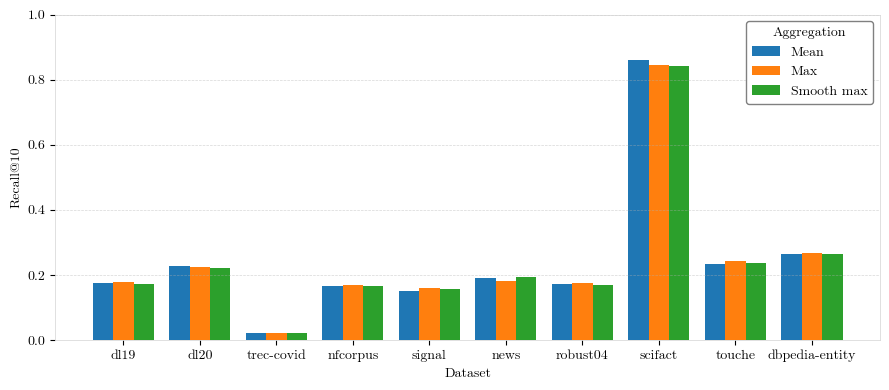

In [54]:
plot_dataset_and_aggregation(list(Dataset), "Recall", 3)
plot_dataset_and_aggregation(list(Dataset), "Recall", 5)
plot_dataset_and_aggregation(list(Dataset), "Recall", 10)

In [99]:
def compare_views(
    log_dir: Path,
    aggregation_strategy: AggregationStrategy,
    max_views: int,
    metric: str = "NDCG",
    metric_k: int = 10,
):
    rows = []

    for dataset in Dataset:
        for view in range(max_views):
            log = MetricsLog.from_run(
                log_dir, aggregation_strategy, dataset, view
            )
            value = log.metrics[metric][metric_k]

            rows.append({
                "dataset": dataset.name if hasattr(dataset, "name") else dataset,
                "view": view,
                "metric": metric,
                "k": metric_k,
                "value": value,
            })
    

    df = pd.DataFrame(rows)
    selected_df = df[df["dataset"].isin([d.name for d in Dataset.beir_datasets()])]
    beir_avg = (
        selected_df
        .groupby("view", as_index=False)["value"]
        .mean()
    )
    return df, beir_avg

def compare_datasets(
    log_dir: Path,
    aggregation_strategy: AggregationStrategy,
    metric: str = "NDCG",
    metric_k: int = 10,
):
    rows = []

    for dataset in Dataset:
        log = MetricsLog.from_run(
            log_dir, aggregation_strategy, dataset
        )
        value = log.metrics[metric][metric_k]

        rows.append({
            "dataset": dataset.name if hasattr(dataset, "name") else dataset,
            "metric": metric,
            "k": metric_k,
            "value": value,
        })

    df = pd.DataFrame(rows)

    selected_df = df[df["dataset"].isin([d.name for d in Dataset.beir_datasets()])]

    beir_avg = selected_df["value"].mean()

    return df, beir_avg


In [115]:
df_mean, mean_beir_avg = compare_views(LOG_DIR, AggregationStrategy.MEAN, max_views=4)
df_mean_pivot = df_mean.pivot(index="dataset", columns="view", values="value").reindex(
    [d.name for d in Dataset]
)
df_mean_pivot = (df_mean_pivot * 100).round(1)
df_mean_pivot["std"] = df_mean_pivot.std(axis=1).round(1)
mean_beir_avg["value"] = (mean_beir_avg["value"] * 100).round(1)

print("Mean aggregation:")
display(df_mean_pivot)
print("Beir avg")
display(mean_beir_avg)

df_mean, mean_beir_avg = compare_datasets(LOG_DIR, AggregationStrategy.MEAN)
df_table = df_mean.copy()
df_table.loc[len(df_table)] = {
    "dataset": "Mean (BEIR)",
    "metric": df_mean["metric"].iloc[0],
    "k": df_mean["k"].iloc[0],
    "value": mean_beir_avg,
}
df_table["value"] = (df_table["value"] * 100).round(1)
display(df_table[["dataset", "value"]])

Mean aggregation:


view,0,1,2,3,std
dataset,,,,,
DL19,73.0,71.9,72.4,72.4,0.4
DL20,68.3,65.8,67.4,67.8,1.1
TREC_COVID,79.8,78.8,79.4,80.4,0.7
NF_CORPUS,35.4,32.5,32.7,35.0,1.5
SIGNAL,32.2,31.8,33.1,32.4,0.5
NEWS,50.4,46.4,49.3,49.1,1.7
ROBUST04,53.4,51.8,54.5,54.2,1.2
SCIFACT,73.4,60.3,65.9,73.4,6.4
TOUCHE,39.8,36.9,39.0,36.4,1.6


Beir avg


,view,value
0,0,51.0
1,1,47.6
2,2,49.6
3,3,50.5


,dataset,value
0,DL19,73.2
1,DL20,68.8
2,TREC_COVID,79.6
3,NF_CORPUS,35.0
4,SIGNAL,32.7
5,NEWS,49.8
6,ROBUST04,54.6
7,SCIFACT,72.5
8,TOUCHE,39.6
9,DB_PEDIA,43.5


In [113]:
df_max, max_beir_avg = compare_views(LOG_DIR, AggregationStrategy.MAX, max_views=4)
df_max_pivot = df_max.pivot(index="dataset", columns="view", values="value").reindex(
    [d.name for d in Dataset]
)
df_max_pivot = (df_max_pivot * 100).round(1)
df_max_pivot["std"] = df_max_pivot.std(axis=1).round(1)

max_beir_avg["value"] = (max_beir_avg["value"] * 100).round(1)
print("Max aggregation:")
display(df_max_pivot)
print("Beir avg")
display(max_beir_avg)

df_max, max_beir_avg = compare_datasets(LOG_DIR, AggregationStrategy.MAX)
df_table = df_max.copy()
df_table.loc[len(df_table)] = {
    "dataset": "Mean (BEIR)",
    "metric": df_max["metric"].iloc[0],
    "k": df_max["k"].iloc[0],
    "value": max_beir_avg,
}
df_table["value"] = (df_table["value"] * 100).round(1)
display(df_table[["dataset", "value"]])

Max aggregation:


view,0,1,2,3,std
dataset,,,,,
DL19,69.6,73.6,69.2,66.1,3.1
DL20,59.9,67.9,63.6,61.0,3.6
TREC_COVID,74.4,79.4,75.0,71.8,3.2
NF_CORPUS,23.6,35.2,29.2,32.5,5.0
SIGNAL,30.6,32.4,24.8,28.1,3.3
NEWS,38.7,48.4,35.5,37.9,5.7
ROBUST04,46.8,54.9,39.8,43.9,6.4
SCIFACT,71.3,71.6,59.5,66.0,5.7
TOUCHE,30.7,41.1,38.0,40.6,4.8


Beir avg


,view,value
0,0,43.8
1,1,50.8
2,2,42.7
3,3,44.8


,dataset,value
0,DL19,73.6
1,DL20,67.9
2,TREC_COVID,79.4
3,NF_CORPUS,35.2
4,SIGNAL,32.4
5,NEWS,48.4
6,ROBUST04,54.9
7,SCIFACT,71.6
8,TOUCHE,41.1
9,DB_PEDIA,43.6
